# Time Series Decomposition Analysis
1. Select a real-world time series dataset from a publicly available open-source repository. Perform the following tasks: 

*In this task, we will analyze the Mauna Loa CO2 dataset which shows carbon dioxide concentrations measured at the Mauna Loa Observatory in Hawaii since the late 1950s.*

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")

# Load the Mauna Loa CO2 dataset
co2_data = sm.datasets.co2.load_pandas().data
co2_data.head() # type: ignore

,co2
1958-03-29,316.1
1958-04-05,317.3
1958-04-12,317.6
1958-04-19,317.5
1958-04-26,316.4


a) Generate a time plot of the data and describe any visible trend or seasonal components. 


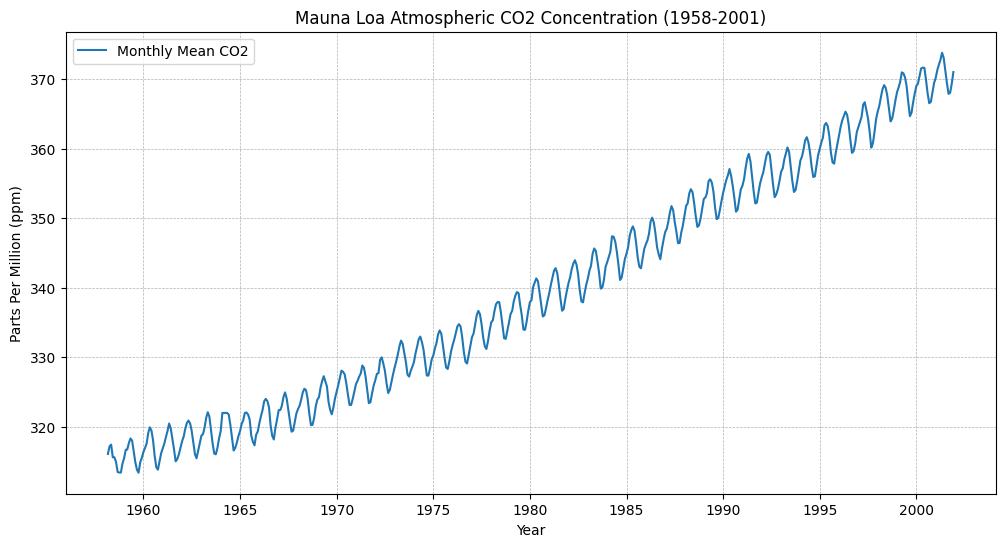

In [7]:
# Clean the data (Resample to Monthly Start 'MS' and fill missing values)
# The raw data is weekly and has some gaps.
y = co2_data['co2'].resample('MS').mean().bfill() #type: ignore

# Generate Time Plot
plt.figure(figsize=(12, 6))
plt.plot(y, label='Monthly Mean CO2', color='#1f77b4')
plt.title('Mauna Loa Atmospheric CO2 Concentration (1958-2001)')
plt.ylabel('Parts Per Million (ppm)')
plt.xlabel('Year')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

**Interpretation:**
- Trend: The plot shows a clear upward trend in CO2 levels over the years, indicating a consistent increase in atmospheric CO2 concentrations.
- Seasonality: There is a noticeable seasonal pattern, with CO2 levels peaking around May each year and dipping around October. This seasonal variation is likely due to the natural processes of plant growth and decay, which affect CO2 absorption and release.

**b) Analyze the variance structure of the series to determine whether an additive or multiplicative decomposition is appropriate.** 

* *An additive decomposition is appropriate here because the seasonal variations appear to be relatively constant over time, rather than increasing or decreasing in proportion to the level of the series. This suggests that the components of the time series (trend, seasonality, and residuals) can be added together to reconstruct the original series.*


**c) Apply the chosen decomposition method and present the resulting trend, seasonal, and random (residual) components using appropriate plots.**

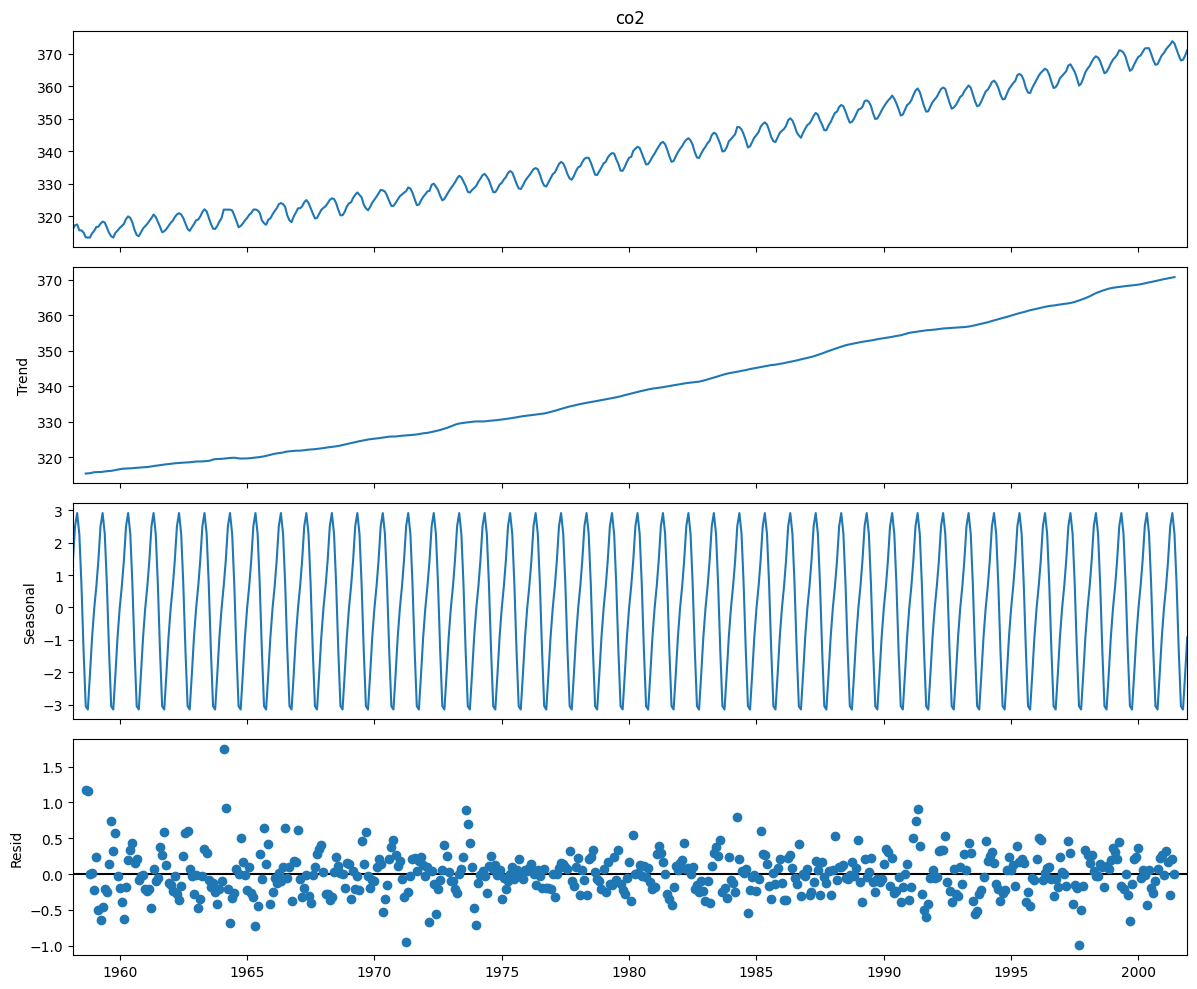

In [8]:
from statsmodels.tsa.seasonal import seasonal_decompose

#  Apply Additive Decomposition
decomposition = seasonal_decompose(y, model='additive', period=12) # Period is 12 for the monthly data

# Plot the resulting components
fig = decomposition.plot()
fig.set_size_inches(12, 10)
plt.tight_layout()
plt.show()

**interpretation:**
- The trend is monotonically increasing, reflecting the overall rise in CO2 levels.
- The seasonal component shows regular fluctuations corresponding to the seasonal cycle observed in the original data.
- The residuals appear to be randomly distributed around zero, indicating that the decomposition has effectively captured the main patterns in the data.

Calculating the Seasonal Variation Using Additive Decomposition: 

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Extract the seasonal component
seasonal_component = decomposition.seasonal

# calculate the variance (The "Strength" of the seasonality)
seasonal_variance = seasonal_component.var()

print(f"Seasonal Variance: {seasonal_variance:.4f}")
print(f"Seasonal Std Dev:  {seasonal_component.std():.4f} ppm")


Seasonal Variance: 4.1110
Seasonal Std Dev:  2.0276 ppm
